In [23]:
import pandas as pd
import os

# Define the file path using a raw string to handle Windows backslashes safely
file_path = r"C:\Users\matias\Documents\Vision-Aided-Beamformer\tests\dataset_out\Avance_1\benchmark_B.parquet"

# Verify if the file exists before attempting to load it
if os.path.exists(file_path):
    # Load the Parquet file into a Pandas DataFrame
    df_metrics = pd.read_parquet(file_path)
    
    # Filter out all rows where rt60 is 0.0 (anechoic conditions) and reset the index
    df_metrics = df_metrics[df_metrics['rt60'] > 0.0].reset_index(drop=True)
    
    print(f"Dataset successfully loaded and filtered (RT60 > 0.0)! Shape: {df_metrics.shape}\n")
    
    # Display the first few rows to confirm data integrity
    display(df_metrics.head())
    
    # Optional: Print all column names to quickly review the available metrics
    # print("Available columns:", df_metrics.columns.tolist())
else:
    print(f"Error: File not found at the specified path:\n{file_path}")
    print("Please check your current working directory using 'import os; print(os.getcwd())'.")

Dataset successfully loaded and filtered (RT60 > 0.0)! Shape: (640, 53)



,processor,rt60,M,N_interferences,mismatch_pos,isir_db,mismatch_gain,mismatch_phase,use_wpe,t_early_s,...,Delta_bf_SIR,Delta_bf_SAR,Delta_bf_SINR,Delta_tot_PESQ,Delta_tot_STOI,Delta_tot_CD,Delta_tot_SDR,Delta_tot_SIR,Delta_tot_SAR,Delta_tot_SINR
0,DS,0.6,9,2,0.0,-5,0,0,False,0.024,...,0.537829,1.316086,1.956183,0.006838,0.022640,-0.602425,0.871075,0.537829,1.316086,1.956183
1,MVDR_(VAD)),0.6,9,2,0.0,-5,0,0,False,0.024,...,1.959852,1.759427,3.431884,0.015624,0.081325,-1.242019,2.284218,1.959852,1.759427,3.431884
2,RTF-MVDR (VAD),0.6,9,2,0.0,-5,0,0,False,0.024,...,7.983599,-2.105330,8.557232,0.014953,0.063885,0.076568,5.109994,7.983599,-2.105330,8.557232
3,MVDR_SPP,0.6,9,2,0.0,-5,0,0,False,0.024,...,1.143955,1.486682,2.660132,0.013003,0.068572,-1.226803,1.471928,1.143955,1.486682,2.660132
4,MPDR,0.6,9,2,0.0,-5,0,0,False,0.024,...,1.483154,1.823283,3.024414,0.011591,0.066687,-1.030856,1.867901,1.483154,1.823283,3.024414


In [24]:
# ==============================================================================
# BLOCK 1: GLOBAL STYLING MACROS AND EXPORT PATHS
# ==============================================================================
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Define the root directory to save all generated figures for the thesis
FIGURES_DIR = r"C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1"
os.makedirs(FIGURES_DIR, exist_ok=True)

# Configure the global plotting style to match academic LaTeX standards
def set_thesis_plot_style():
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Uses a serif font and sizes appropriate for an A4 LaTeX document.
    """
    sns.set_theme(style="whitegrid", context="paper")
    
    plt.rcParams.update({
        "font.family": "serif",          # Matches standard LaTeX font
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 11,                 # Base font size
        "axes.titlesize": 12,            # Subplot title size
        "axes.labelsize": 11,            # X and Y label size
        "xtick.labelsize": 9,            # Tick labels
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "legend.title_fontsize": 10,
        "figure.titlesize": 13,
        "figure.dpi": 300,               # High resolution for print
        "savefig.dpi": 300,
        "savefig.bbox": "tight",         # Removes unnecessary white space
        "lines.linewidth": 1,
        "lines.markersize": 5
    })

# Apply the style settings
set_thesis_plot_style()

In [ ]:
def set_presentation_plot_style(dark_theme=True):
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Optimized for presentation slides with larger fonts and thicker lines.
    """
    sns.set_theme(style="darkgrid" if dark_theme else "whitegrid", context="talk")
    bg_color = "#050505" if dark_theme else "#FFFFFF"
    text_color = "#F5F5F5" if dark_theme else "#111111"
    grid_color = "#222222" if dark_theme else "#E0E0E0"

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Urbanist", "Arial", "sans-serif"],
        "font.size": 16,
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 6,
        "figure.facecolor": bg_color,
        "axes.facecolor": bg_color,
        "axes.edgecolor": grid_color,
        "axes.labelcolor": text_color,
        "text.color": text_color,
        "xtick.color": text_color,
        "ytick.color": text_color,
    })

def plot_robustness_heatmaps(df_results):
    """
    Generates a 2x2 grid of heatmaps displaying algorithm robustness 
    against different compounded stress scenarios for PESQ, STOI, SIR, and SDR.
    """
    # Apply dark presentation style
    set_presentation_plot_style(dark_theme=True)
    
    # 1. Classify the raw data into distinct stress scenarios
    def categorize_scenario(row):
        hw_err = (row['mismatch_gain'] > 0) or (row['mismatch_phase'] > 0)
        pos_err = (row['error_angle_deg'] > 0) or (row['error_distance_m'] > 0)
        
        if not hw_err and not pos_err:
            return "1. Nominal\n(Ideal)"
        elif not hw_err and pos_err:
            return "2. Pos Error\n(DOA/Dist)"
        elif hw_err and not pos_err:
            return "3. HW Error\n(Gain/Phase)"
        else:
            return "4. Extreme\n(Combined)"

    # Create a copy to avoid SettingWithCopyWarning and apply categorization
    df = df_results.copy()
    df['Stress_Scenario'] = df.apply(categorize_scenario, axis=1)
    
    # 2. Setup the 2x2 subplot grid
    metrics = ['Delta_tot_PESQ', 'Delta_tot_STOI', 'Delta_tot_SIR', 'Delta_tot_SDR']
    titles = ['Improvement: Δ PESQ', 'Improvement: Δ STOI', 'Improvement: Δ SIR (dB)', 'Improvement: Δ SDR (dB)']
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()
    
    # Colormap selection: 'magma' or 'viridis' look excellent on dark backgrounds
    cmap = "viridis"
    
    for i, metric in enumerate(metrics):
        if metric not in df.columns:
            continue
            
        # Create pivot table for the heatmap: Rows=Algorithms, Columns=Scenarios
        pivot_df = df.pivot_table(
            index='processor', 
            columns='Stress_Scenario', 
            values=metric, 
            aggfunc='mean' # Averages out other variables (like RT60 or N_interferences) if present
        )
        
        # Plot heatmap on the specific axis
        sns.heatmap(
            pivot_df, 
            ax=axes[i], 
            cmap=cmap, 
            annot=True,          # Show numerical values inside cells
            fmt=".2f",           # 2 decimal places
            linewidths=1.5,      # Add spacing between cells for better readability
            linecolor='#050505', # Match background color for cell borders
            cbar_kws={'shrink': 0.8}
        )
        
        # Format subplot labels
        axes[i].set_title(titles[i], pad=15, color="#deff9a", fontweight="bold")
        axes[i].set_ylabel("")
        axes[i].set_xlabel("")
        
        # Rotate X labels for better fit
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].tick_params(axis='y', rotation=0)

    # Adjust layout to prevent overlap
    plt.suptitle("Experiment B: Algorithm Robustness Matrix", fontsize=28, color="#f5f5f5", y=1.02, fontweight="bold")
    plt.tight_layout()
    plt.show()
    # Save the figure with presentation-ready settings
    plt.savefig('experiment_b_robustness_matrix.png', dpi=300, bbox_inches='tight')
    plt.close()

plot_robustness_heatmaps(df_metrics)

KeyError: 'error_angle_deg'

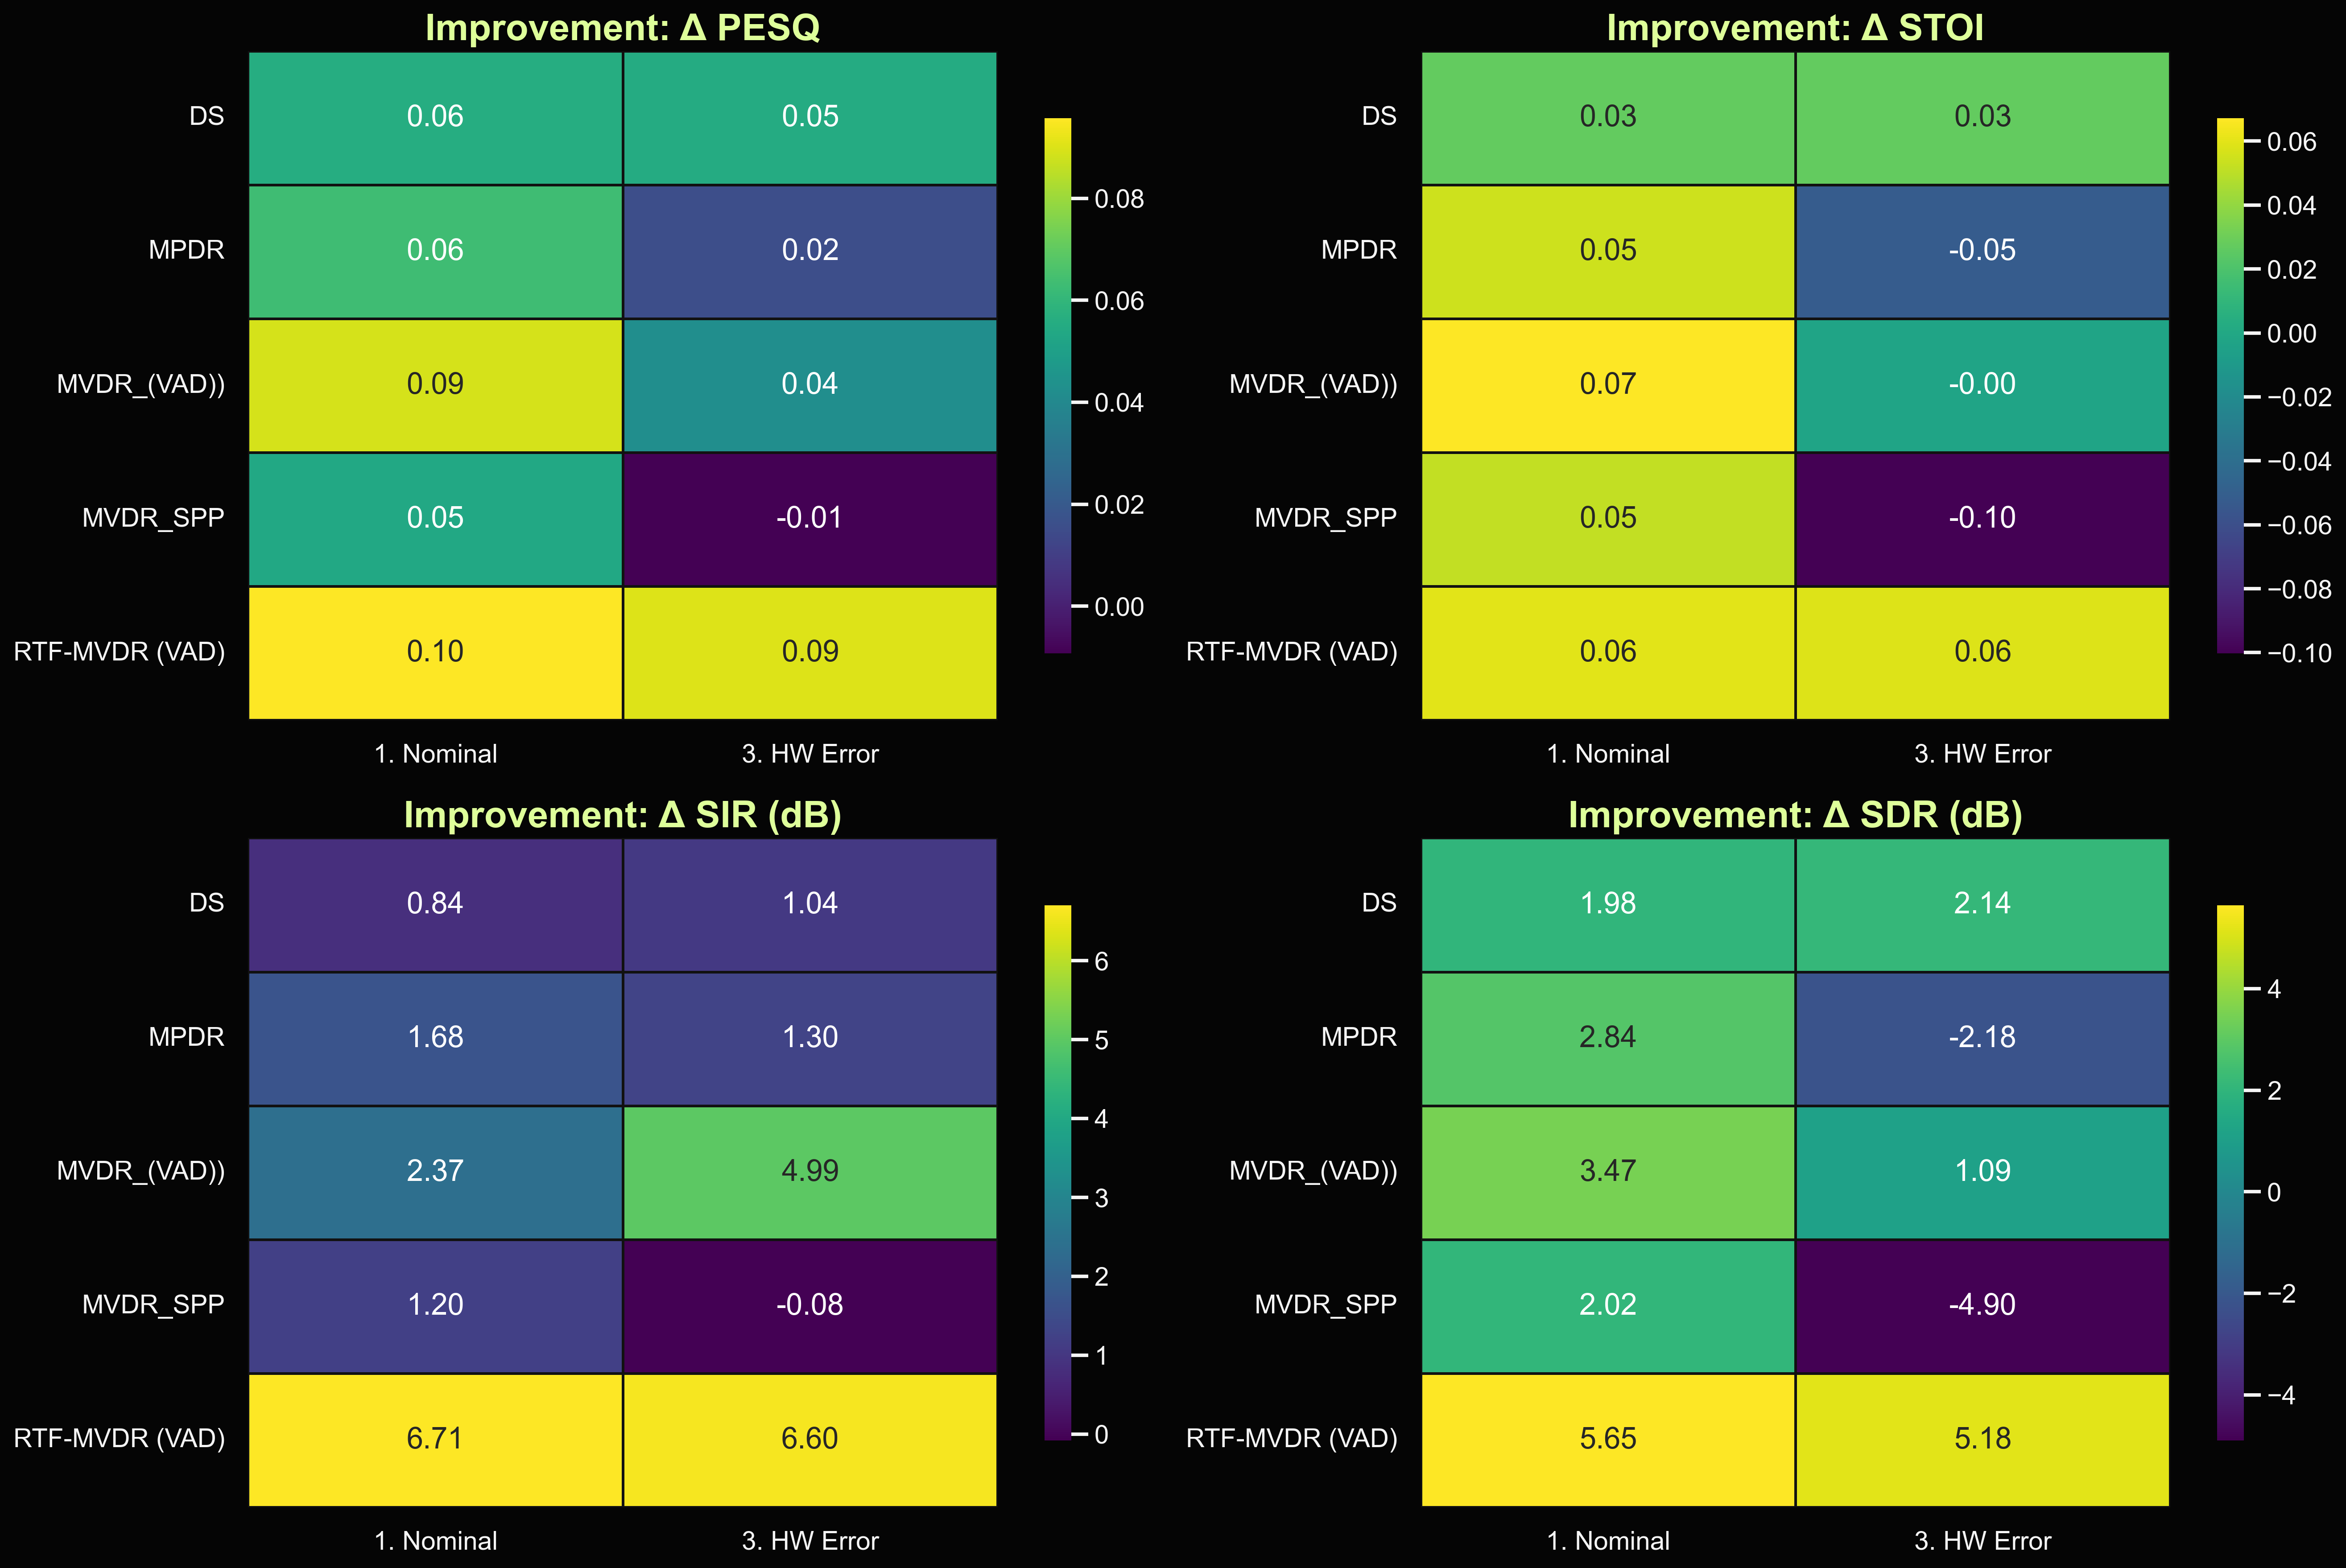

In [39]:
def plot_robustness_heatmaps(df_results):
    """
    Generates 2x2 heatmaps of performance metrics based on existing DataFrame columns.
    """
    set_presentation_plot_style(dark_theme=True)
    
    # 1. Classification based on your specific columns
    def categorize_scenario(row):
        # We define errors based on the columns you reported
        pos_err = (row.get('mismatch_pos', 0) > 0)
        hw_err = (row.get('mismatch_gain', 0) > 0) or (row.get('mismatch_phase', 0) > 0)
        
        if not hw_err and not pos_err:
            return "1. Nominal"
        elif not hw_err and pos_err:
            return "2. Pos Error"
        elif hw_err and not pos_err:
            return "3. HW Error"
        else:
            return "4. Extreme"

    df = df_results.copy()
    df['Stress_Scenario'] = df.apply(categorize_scenario, axis=1)
    
    # 2. Metric selection (Using exactly the 'Delta_tot_' columns you have)
    metrics = ['Delta_tot_PESQ', 'Delta_tot_STOI', 'Delta_tot_SIR', 'Delta_tot_SDR']
    titles = ['Improvement: Δ PESQ', 'Improvement: Δ STOI', 'Improvement: Δ SIR (dB)', 'Improvement: Δ SDR (dB)']
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, metric in enumerate(metrics):
        # Pivot by processor (rows) and the new stress scenario (columns)
        pivot_df = df.pivot_table(index='processor', columns='Stress_Scenario', values=metric, aggfunc='mean')
        
        sns.heatmap(pivot_df, ax=axes[i], cmap="viridis", annot=True, fmt=".2f", 
                    linewidths=1.0, linecolor='#111', cbar_kws={'shrink': 0.8})
        
        axes[i].set_title(titles[i], color="#deff9a", fontweight="bold")
        axes[i].set_ylabel("")
        axes[i].set_xlabel("")

    plt.tight_layout()
    plt.show() # ADDED: This explicitly tells the notebook to render the image
plot_robustness_heatmaps(df_metrics)

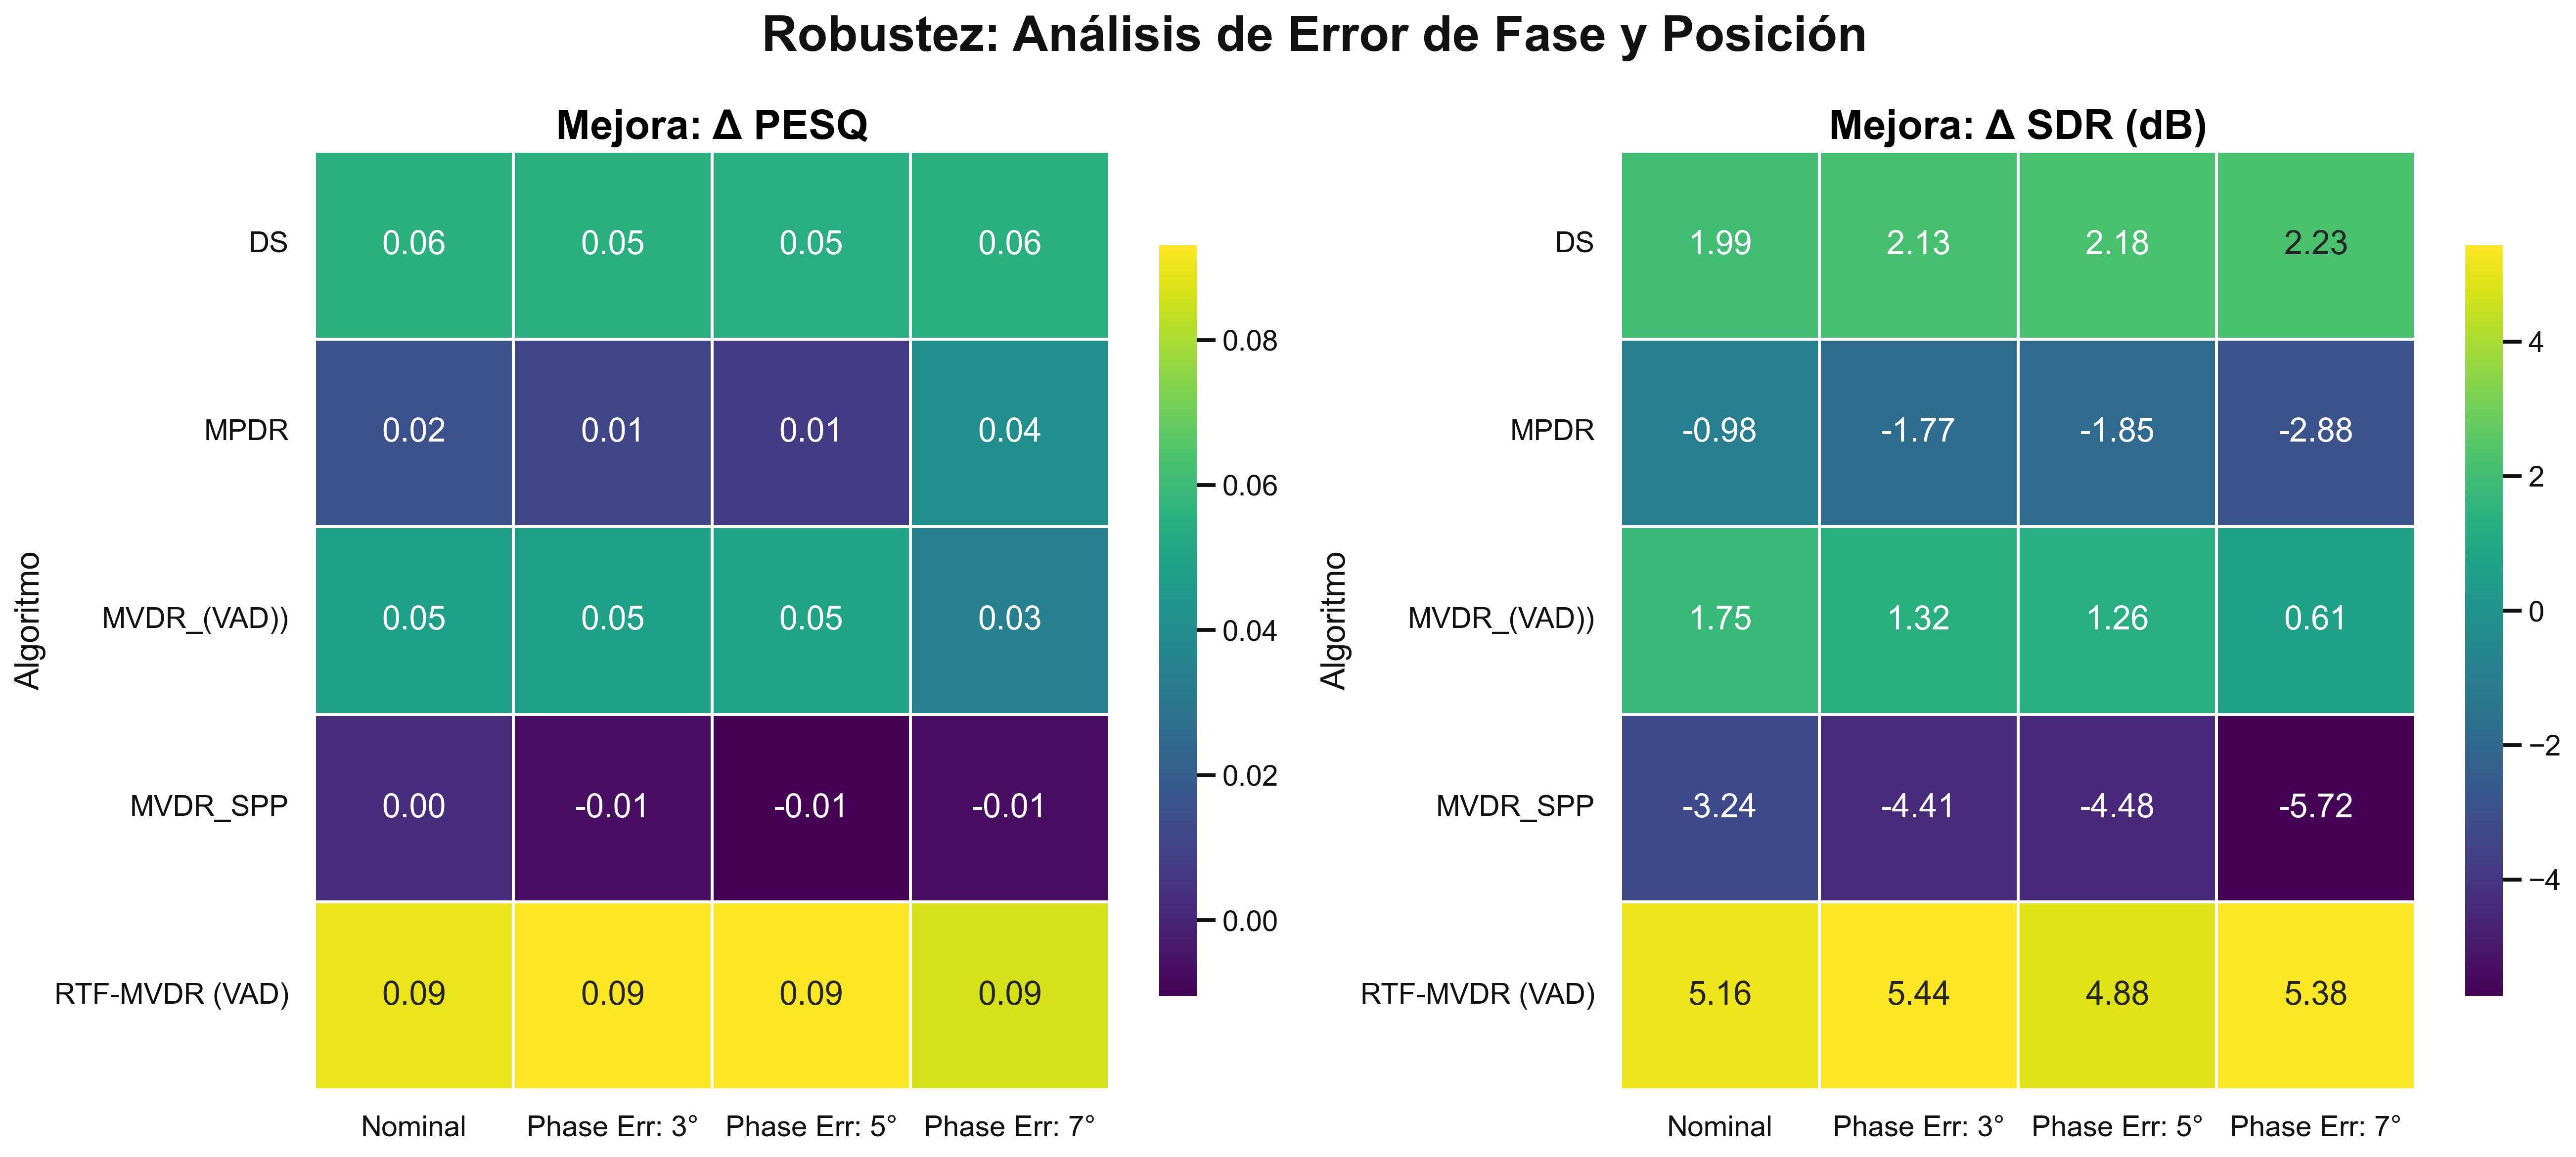

In [43]:
# ==============================================================================
# BLOCK: GLOBAL PERFORMANCE (PESQ & SDR ONLY) - PRESENTATION OPTIMIZED
# ==============================================================================
def plot_robustness_heatmaps(df_results):
    """
    Generates 1x2 heatmaps for PESQ and SDR, using specific phase error values.
    Optimized for presentation (white background).
    """
    # Use white background for presentation
    set_presentation_plot_style(dark_theme=False)
    
    # 1. Classification: Maps 'mismatch_phase' to specific labels for the presentation
    def categorize_scenario(row):
        pos_err = (row.get('mismatch_pos', 0) > 0)
        phase_err = row.get('mismatch_phase', 0)
        
        if not (phase_err > 0) and not pos_err:
            return "Nominal"
        elif not (phase_err > 0) and pos_err:
            return "Pos Error"
        else:
            return f"Phase Err: {int(phase_err)}°"

    df = df_results.copy()
    df['Escenario'] = df.apply(categorize_scenario, axis=1)
    
    # 2. Select only PESQ and SDR
    metrics = ['Delta_tot_PESQ', 'Delta_tot_SDR']
    titles = ['Mejora: Δ PESQ', 'Mejora: Δ SDR (dB)']
    
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    
    for i, metric in enumerate(metrics):
        # Pivot by processor (rows) and the new scenario (columns)
        pivot_df = df.pivot_table(index='processor', columns='Escenario', values=metric, aggfunc='mean')
        
        sns.heatmap(pivot_df, ax=axes[i], cmap="viridis", annot=True, fmt=".2f", 
                    linewidths=1.0, linecolor='#FFFFFF', cbar_kws={'shrink': 0.8})
        
        axes[i].set_title(titles[i], color="#000000", fontweight="bold")
        axes[i].set_ylabel("Algoritmo")
        axes[i].set_xlabel("")

    plt.suptitle("Robustez: Análisis de Error de Fase y Posición", fontsize=24, fontweight="bold")
    plt.tight_layout()
    plt.show()
# Execute
plot_robustness_heatmaps(df_metrics)

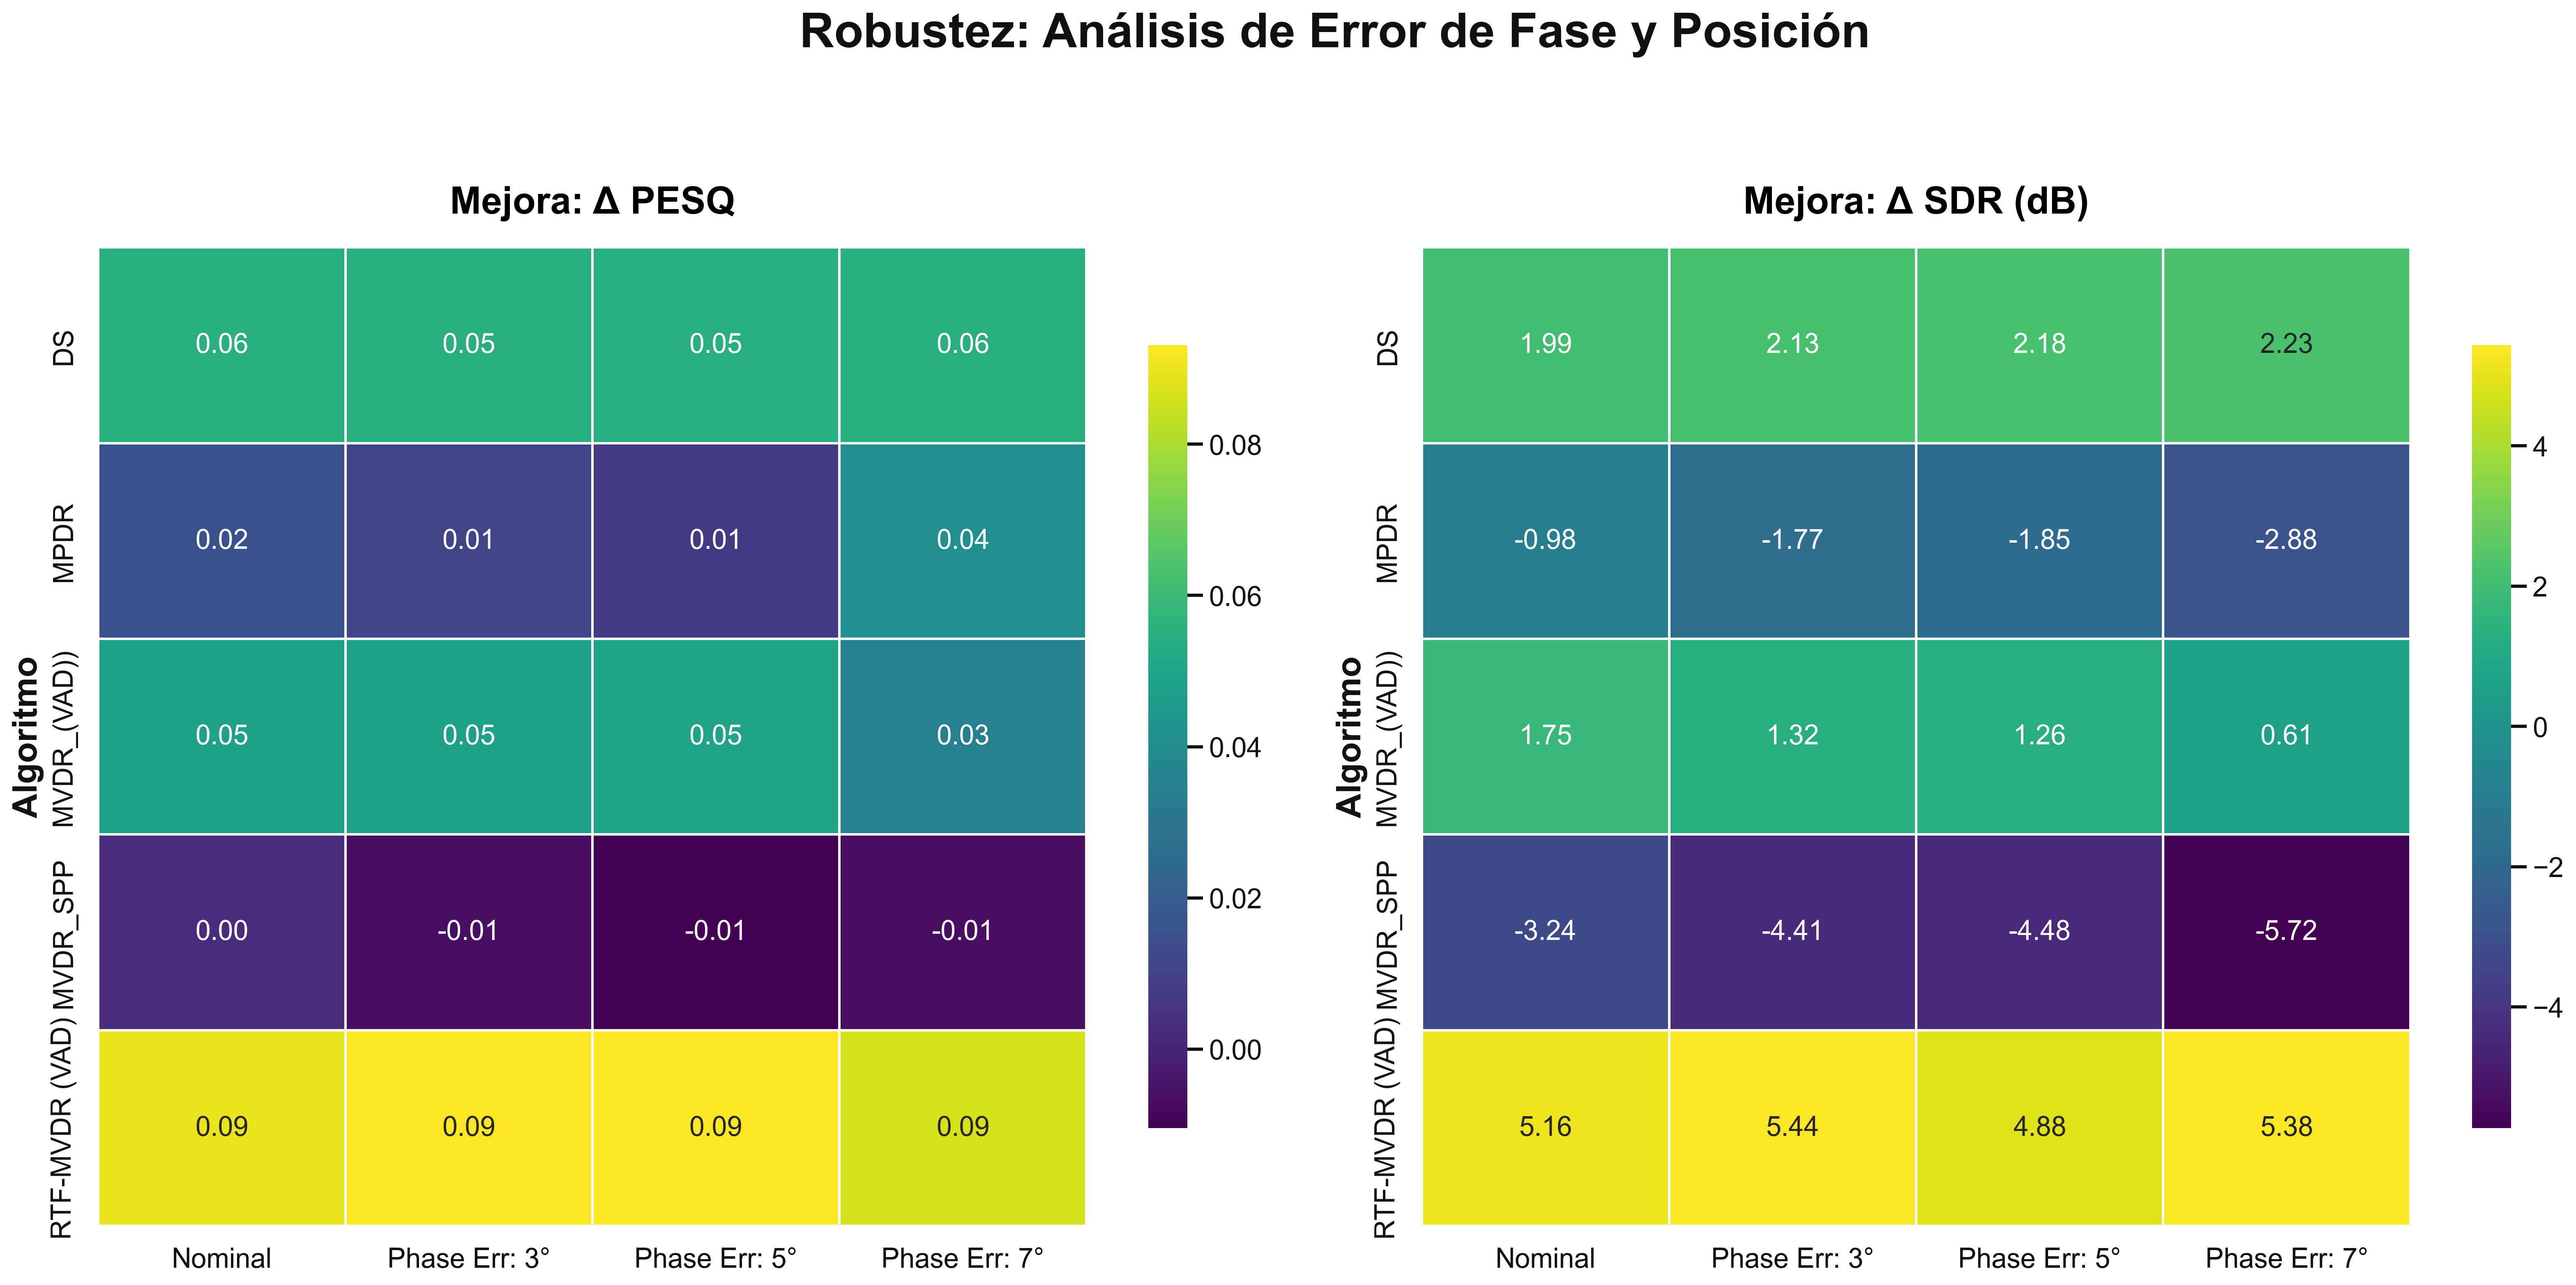

In [44]:
# ==============================================================================
# BLOCK: GLOBAL PERFORMANCE (PESQ & SDR ONLY) - PRESENTATION OPTIMIZED
# ==============================================================================
def plot_robustness_heatmaps(df_results):
    """
    Generates 1x2 heatmaps for PESQ and SDR, using specific phase error values.
    Optimized for presentation (white background and large fonts).
    """
    # Use white background for presentation
    set_presentation_plot_style(dark_theme=False)
    
    # Configure font sizes for presentation
    plt.rcParams.update({
        'font.size': 18,
        'axes.titlesize': 22,
        'axes.labelsize': 20,
        'xtick.labelsize': 16,
        'ytick.labelsize': 16,
        'legend.fontsize': 16
    })
    
    # 1. Classification: Maps 'mismatch_phase' to specific labels for the presentation
    def categorize_scenario(row):
        # Determine position error
        pos_err = (row.get('mismatch_pos', 0) > 0)
        # Determine phase error
        phase_err = row.get('mismatch_phase', 0)
        
        if not (phase_err > 0) and not pos_err:
            return "Nominal"
        elif not (phase_err > 0) and pos_err:
            return "Pos Error"
        else:
            return f"Phase Err: {int(phase_err)}°"

    df = df_results.copy()
    df['Escenario'] = df.apply(categorize_scenario, axis=1)
    
    # 2. Select only PESQ and SDR
    metrics = ['Delta_tot_PESQ', 'Delta_tot_SDR']
    titles = ['Mejora: Δ PESQ', 'Mejora: Δ SDR (dB)']
    
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))
    
    for i, metric in enumerate(metrics):
        # Pivot by processor (rows) and the new scenario (columns)
        pivot_df = df.pivot_table(index='processor', columns='Escenario', values=metric, aggfunc='mean')
        
        # Draw heatmap
        sns.heatmap(pivot_df, ax=axes[i], cmap="viridis", annot=True, fmt=".2f", 
                    linewidths=1.0, linecolor='#FFFFFF', cbar_kws={'shrink': 0.8},
                    annot_kws={"size": 16})
        
        axes[i].set_title(titles[i], color="#000000", fontweight="bold", pad=20)
        axes[i].set_ylabel("Algoritmo", fontweight="bold")
        axes[i].set_xlabel("")

    plt.suptitle("Robustez: Análisis de Error de Fase y Posición", fontsize=28, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()

# Execute
plot_robustness_heatmaps(df_metrics)

In [45]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def set_presentation_plot_style(dark_theme=True):
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Optimized for presentation slides with larger fonts and thicker lines.
    """
    sns.set_theme(style="darkgrid" if dark_theme else "whitegrid", context="talk")
    bg_color = "#050505" if dark_theme else "#FFFFFF"
    text_color = "#F5F5F5" if dark_theme else "#111111"
    grid_color = "#222222" if dark_theme else "#E0E0E0"

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Urbanist", "Arial", "sans-serif"],
        "font.size": 16,
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "figure.facecolor": bg_color,
        "axes.facecolor": bg_color,
        "axes.edgecolor": grid_color,
        "axes.labelcolor": text_color,
        "text.color": text_color,
        "xtick.color": text_color,
        "ytick.color": text_color,
    })

def plot_robustness_heatmaps(df_results):
    """
    Generates a 2x2 grid of heatmaps displaying algorithm robustness 
    against different compounded stress scenarios for PESQ, STOI, SIR, and SDR.
    """
    # Apply dark presentation style
    set_presentation_plot_style(dark_theme=True)
    
    # 1. Classify the raw data into distinct stress scenarios
    def categorize_scenario(row):
        hw_err = (row['mismatch_gain'] > 0) or (row['mismatch_phase'] > 0)
        pos_err = (row['error_angle_deg'] > 0) or (row['error_distance_m'] > 0)
        
        if not hw_err and not pos_err:
            return "1. Nominal\n(Ideal)"
        elif not hw_err and pos_err:
            return "2. Pos Error\n(DOA/Dist)"
        elif hw_err and not pos_err:
            return "3. HW Error\n(Gain/Phase)"
        else:
            return "4. Extreme\n(Combined)"

    # Create a copy to avoid SettingWithCopyWarning and apply categorization
    df = df_results.copy()
    df['Stress_Scenario'] = df.apply(categorize_scenario, axis=1)
    
    # 2. Setup the 2x2 subplot grid
    metrics = ['Delta_tot_PESQ', 'Delta_tot_STOI', 'Delta_tot_SIR', 'Delta_tot_SDR']
    titles = ['Improvement: Δ PESQ', 'Improvement: Δ STOI', 'Improvement: Δ SIR (dB)', 'Improvement: Δ SDR (dB)']
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()
    
    # Colormap selection: 'magma' or 'viridis' look excellent on dark backgrounds
    cmap = "viridis"
    
    for i, metric in enumerate(metrics):
        if metric not in df.columns:
            continue
            
        # Create pivot table for the heatmap: Rows=Algorithms, Columns=Scenarios
        pivot_df = df.pivot_table(
            index='processor', 
            columns='Stress_Scenario', 
            values=metric, 
            aggfunc='mean' # Averages out other variables (like RT60 or N_interferences) if present
        )
        
        # Plot heatmap on the specific axis
        sns.heatmap(
            pivot_df, 
            ax=axes[i], 
            cmap=cmap, 
            annot=True,          # Show numerical values inside cells
            fmt=".2f",           # 2 decimal places
            linewidths=1.5,      # Add spacing between cells for better readability
            linecolor='#050505', # Match background color for cell borders
            cbar_kws={'shrink': 0.8}
        )
        
        # Format subplot labels
        axes[i].set_title(titles[i], pad=15, color="#deff9a", fontweight="bold")
        axes[i].set_ylabel("")
        axes[i].set_xlabel("")
        
        # Rotate X labels for better fit
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].tick_params(axis='y', rotation=0)

    # Adjust layout to prevent overlap
    plt.suptitle("Experiment B: Algorithm Robustness Matrix", fontsize=28, color="#f5f5f5", y=1.02, fontweight="bold")
    plt.tight_layout()
    
    # Save the figure with presentation-ready settings
    plt.savefig('experiment_b_robustness_matrix.png', dpi=300, bbox_inches='tight')
    plt.close()

# --- Example Usage ---
# Assuming 'df_B' is the DataFrame resulting from your run_grid_search for Experiment B
plot_robustness_heatmaps(df_metrics)

KeyError: 'error_angle_deg'

In [46]:
def set_presentation_plot_style(dark_theme=True):
    """
    Applies global formatting rules for Matplotlib and Seaborn.
    Optimized for presentation slides with larger fonts and thicker lines.
    """
    sns.set_theme(style="darkgrid" if dark_theme else "whitegrid", context="talk")
    bg_color = "#050505" if dark_theme else "#FFFFFF"
    text_color = "#F5F5F5" if dark_theme else "#111111"
    grid_color = "#222222" if dark_theme else "#E0E0E0"

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Urbanist", "Arial", "sans-serif"],
        "font.size": 16,
        "axes.titlesize": 20,
        "axes.labelsize": 16,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "figure.facecolor": bg_color,
        "axes.facecolor": bg_color,
        "axes.edgecolor": grid_color,
        "axes.labelcolor": text_color,
        "text.color": text_color,
        "xtick.color": text_color,
        "ytick.color": text_color,
    })

def plot_robustness_heatmaps(df_results):
    """
    Generates a 2x2 grid of heatmaps displaying algorithm robustness 
    against different compounded stress scenarios for PESQ, STOI, SIR, and SDR.
    """
    # Apply dark presentation style
    set_presentation_plot_style(dark_theme=True)
    
    # 1. Classify the raw data into distinct stress scenarios
    def categorize_scenario(row):
        hw_err = (row['mismatch_gain'] > 0) or (row['mismatch_phase'] > 0)
        pos_err = (row['error_angle_deg'] > 0) or (row['error_distance_m'] > 0)
        
        if not hw_err and not pos_err:
            return "1. Nominal\n(Ideal)"
        elif not hw_err and pos_err:
            return "2. Pos Error\n(DOA/Dist)"
        elif hw_err and not pos_err:
            return "3. HW Error\n(Gain/Phase)"
        else:
            return "4. Extreme\n(Combined)"

    # Create a copy to avoid SettingWithCopyWarning and apply categorization
    df = df_results.copy()
    df['Stress_Scenario'] = df.apply(categorize_scenario, axis=1)
    
    # 2. Setup the 2x2 subplot grid
    metrics = ['Delta_tot_PESQ', 'Delta_tot_STOI', 'Delta_tot_SIR', 'Delta_tot_SDR']
    titles = ['Improvement: Δ PESQ', 'Improvement: Δ STOI', 'Improvement: Δ SIR (dB)', 'Improvement: Δ SDR (dB)']
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()
    
    # Colormap selection: 'magma' or 'viridis' look excellent on dark backgrounds
    cmap = "viridis"
    
    for i, metric in enumerate(metrics):
        if metric not in df.columns:
            continue
            
        # Create pivot table for the heatmap: Rows=Algorithms, Columns=Scenarios
        pivot_df = df.pivot_table(
            index='processor', 
            columns='Stress_Scenario', 
            values=metric, 
            aggfunc='mean' # Averages out other variables (like RT60 or N_interferences) if present
        )
        
        # Plot heatmap on the specific axis
        sns.heatmap(
            pivot_df, 
            ax=axes[i], 
            cmap=cmap, 
            annot=True,          # Show numerical values inside cells
            fmt=".2f",           # 2 decimal places
            linewidths=1.5,      # Add spacing between cells for better readability
            linecolor='#050505', # Match background color for cell borders
            cbar_kws={'shrink': 0.8}
        )
        
        # Format subplot labels
        axes[i].set_title(titles[i], pad=15, color="#deff9a", fontweight="bold")
        axes[i].set_ylabel("")
        axes[i].set_xlabel("")
        
        # Rotate X labels for better fit
        axes[i].tick_params(axis='x', rotation=0)
        axes[i].tick_params(axis='y', rotation=0)

    # Adjust layout to prevent overlap
    plt.suptitle("Experiment B: Algorithm Robustness Matrix", fontsize=28, color="#f5f5f5", y=1.02, fontweight="bold")
    plt.tight_layout()
    
    # Save the figure with presentation-ready settings
    plt.show()

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\mics_no_wpe.pdf


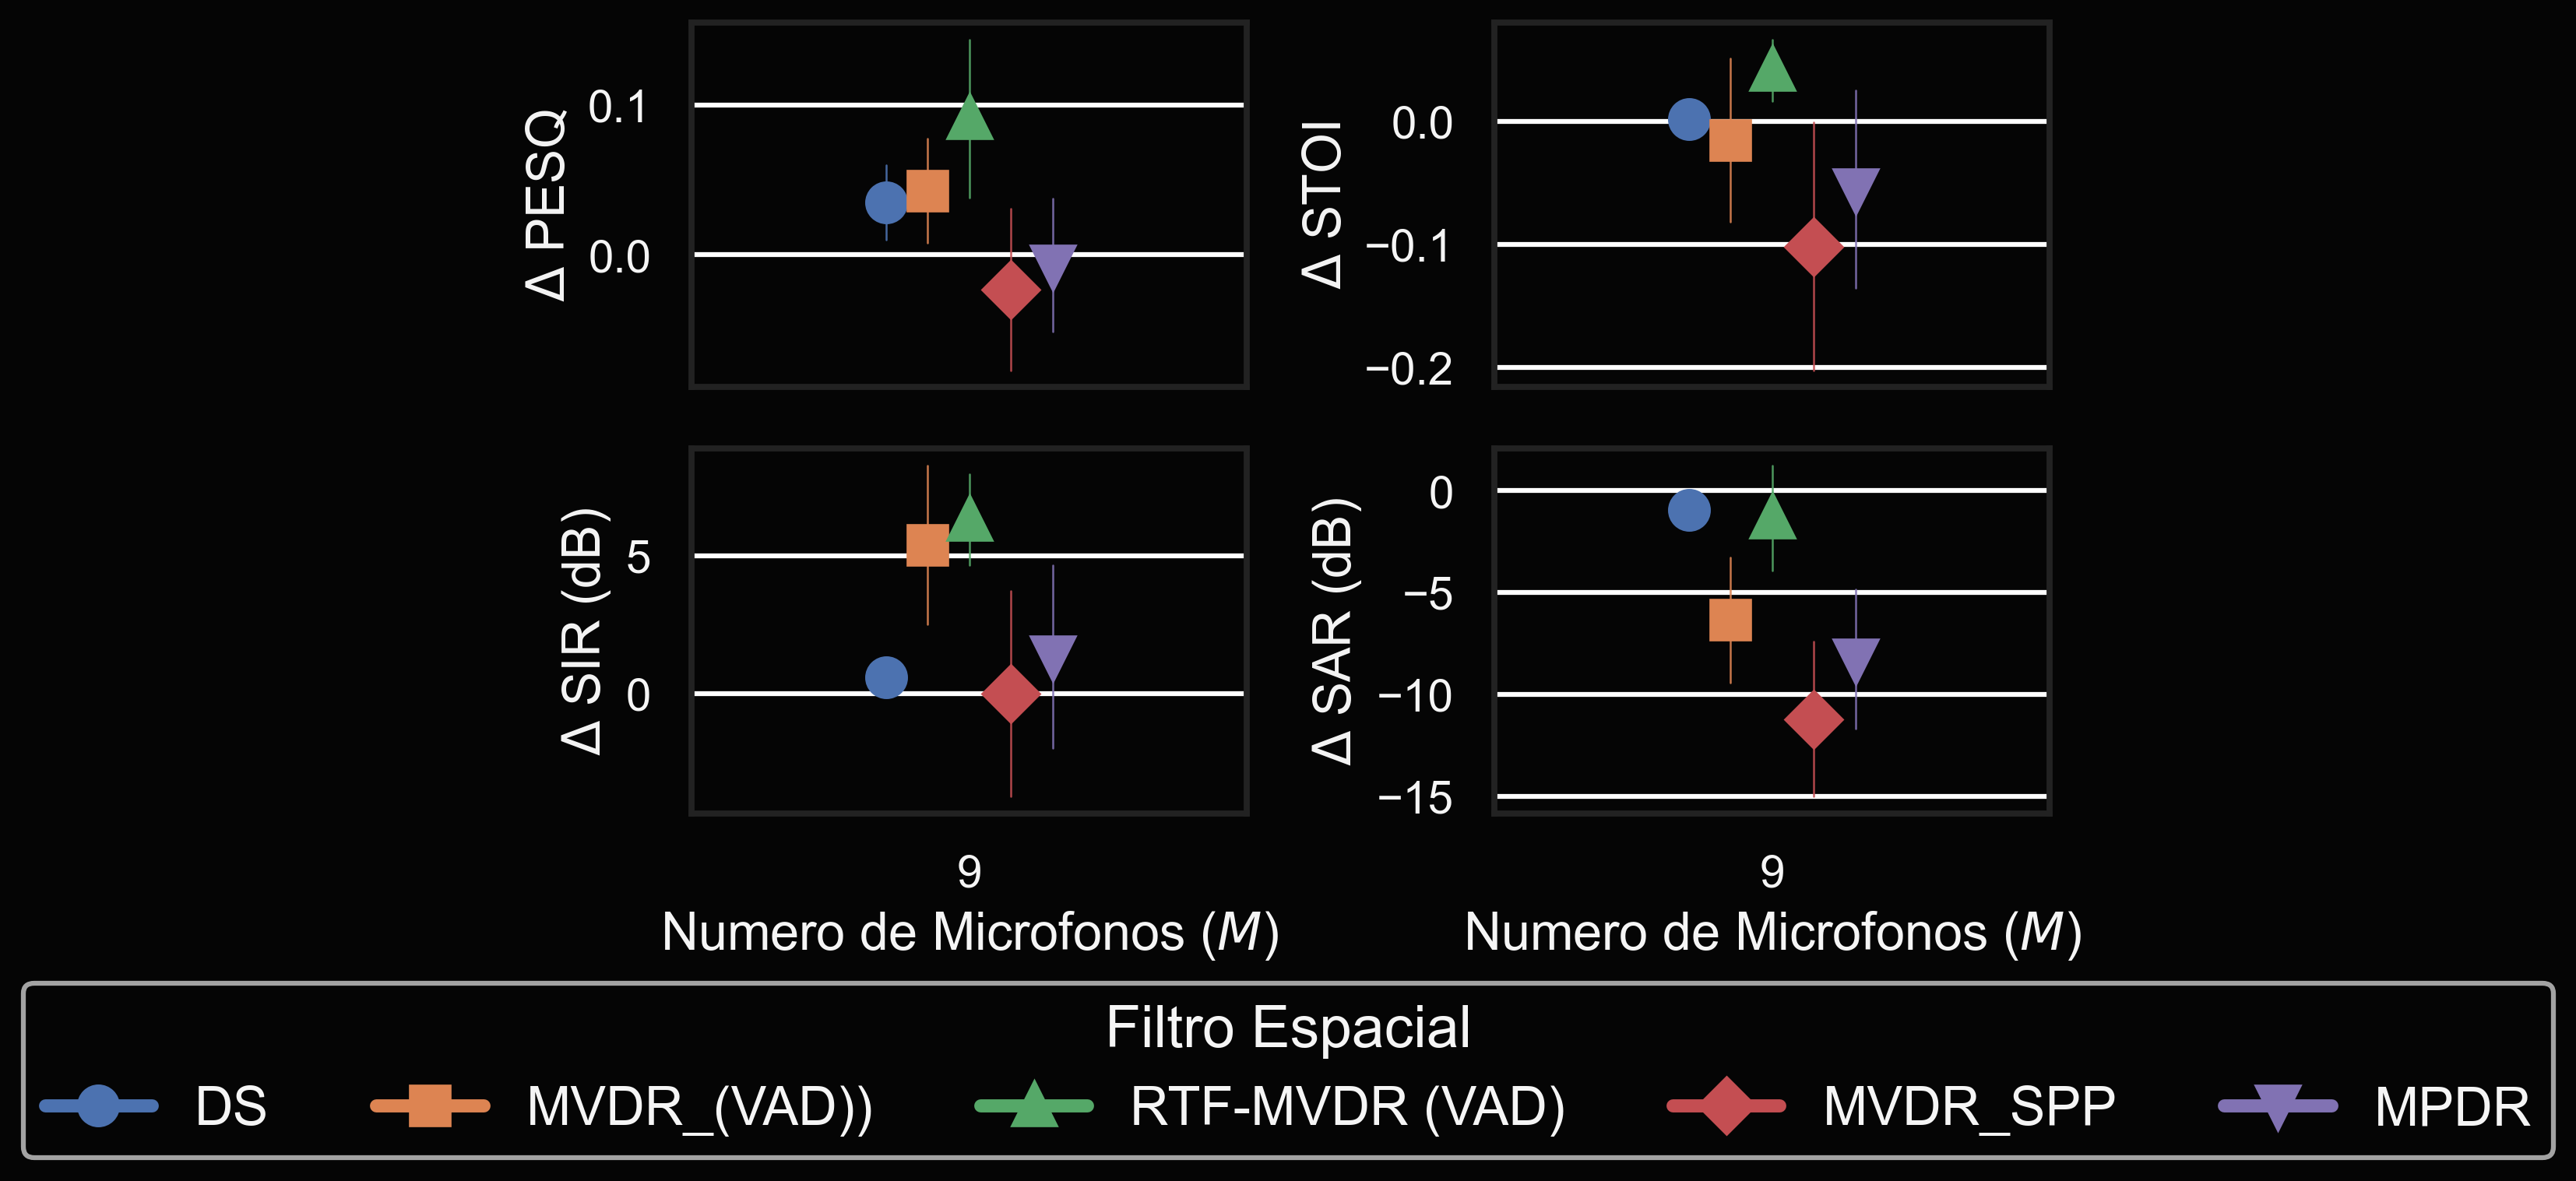

In [47]:
# ==============================================================================
# BLOCK 2: GENERATE BEAMFORMER PERFORMANCE PLOT (WITHOUT WPE) - COMPACT Y-LABELS
# ==============================================================================

def plot_beamformer_deltas_vs_m_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis 
    to maximize plotting area.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == True].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    # Height adjusted back to 5.0 since we removed the titles
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='M', 
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Numero de Microfonos ($M$)')
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Filtro Espacial',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "mics_no_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_m_compact(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\deltas_vs_interferences.pdf


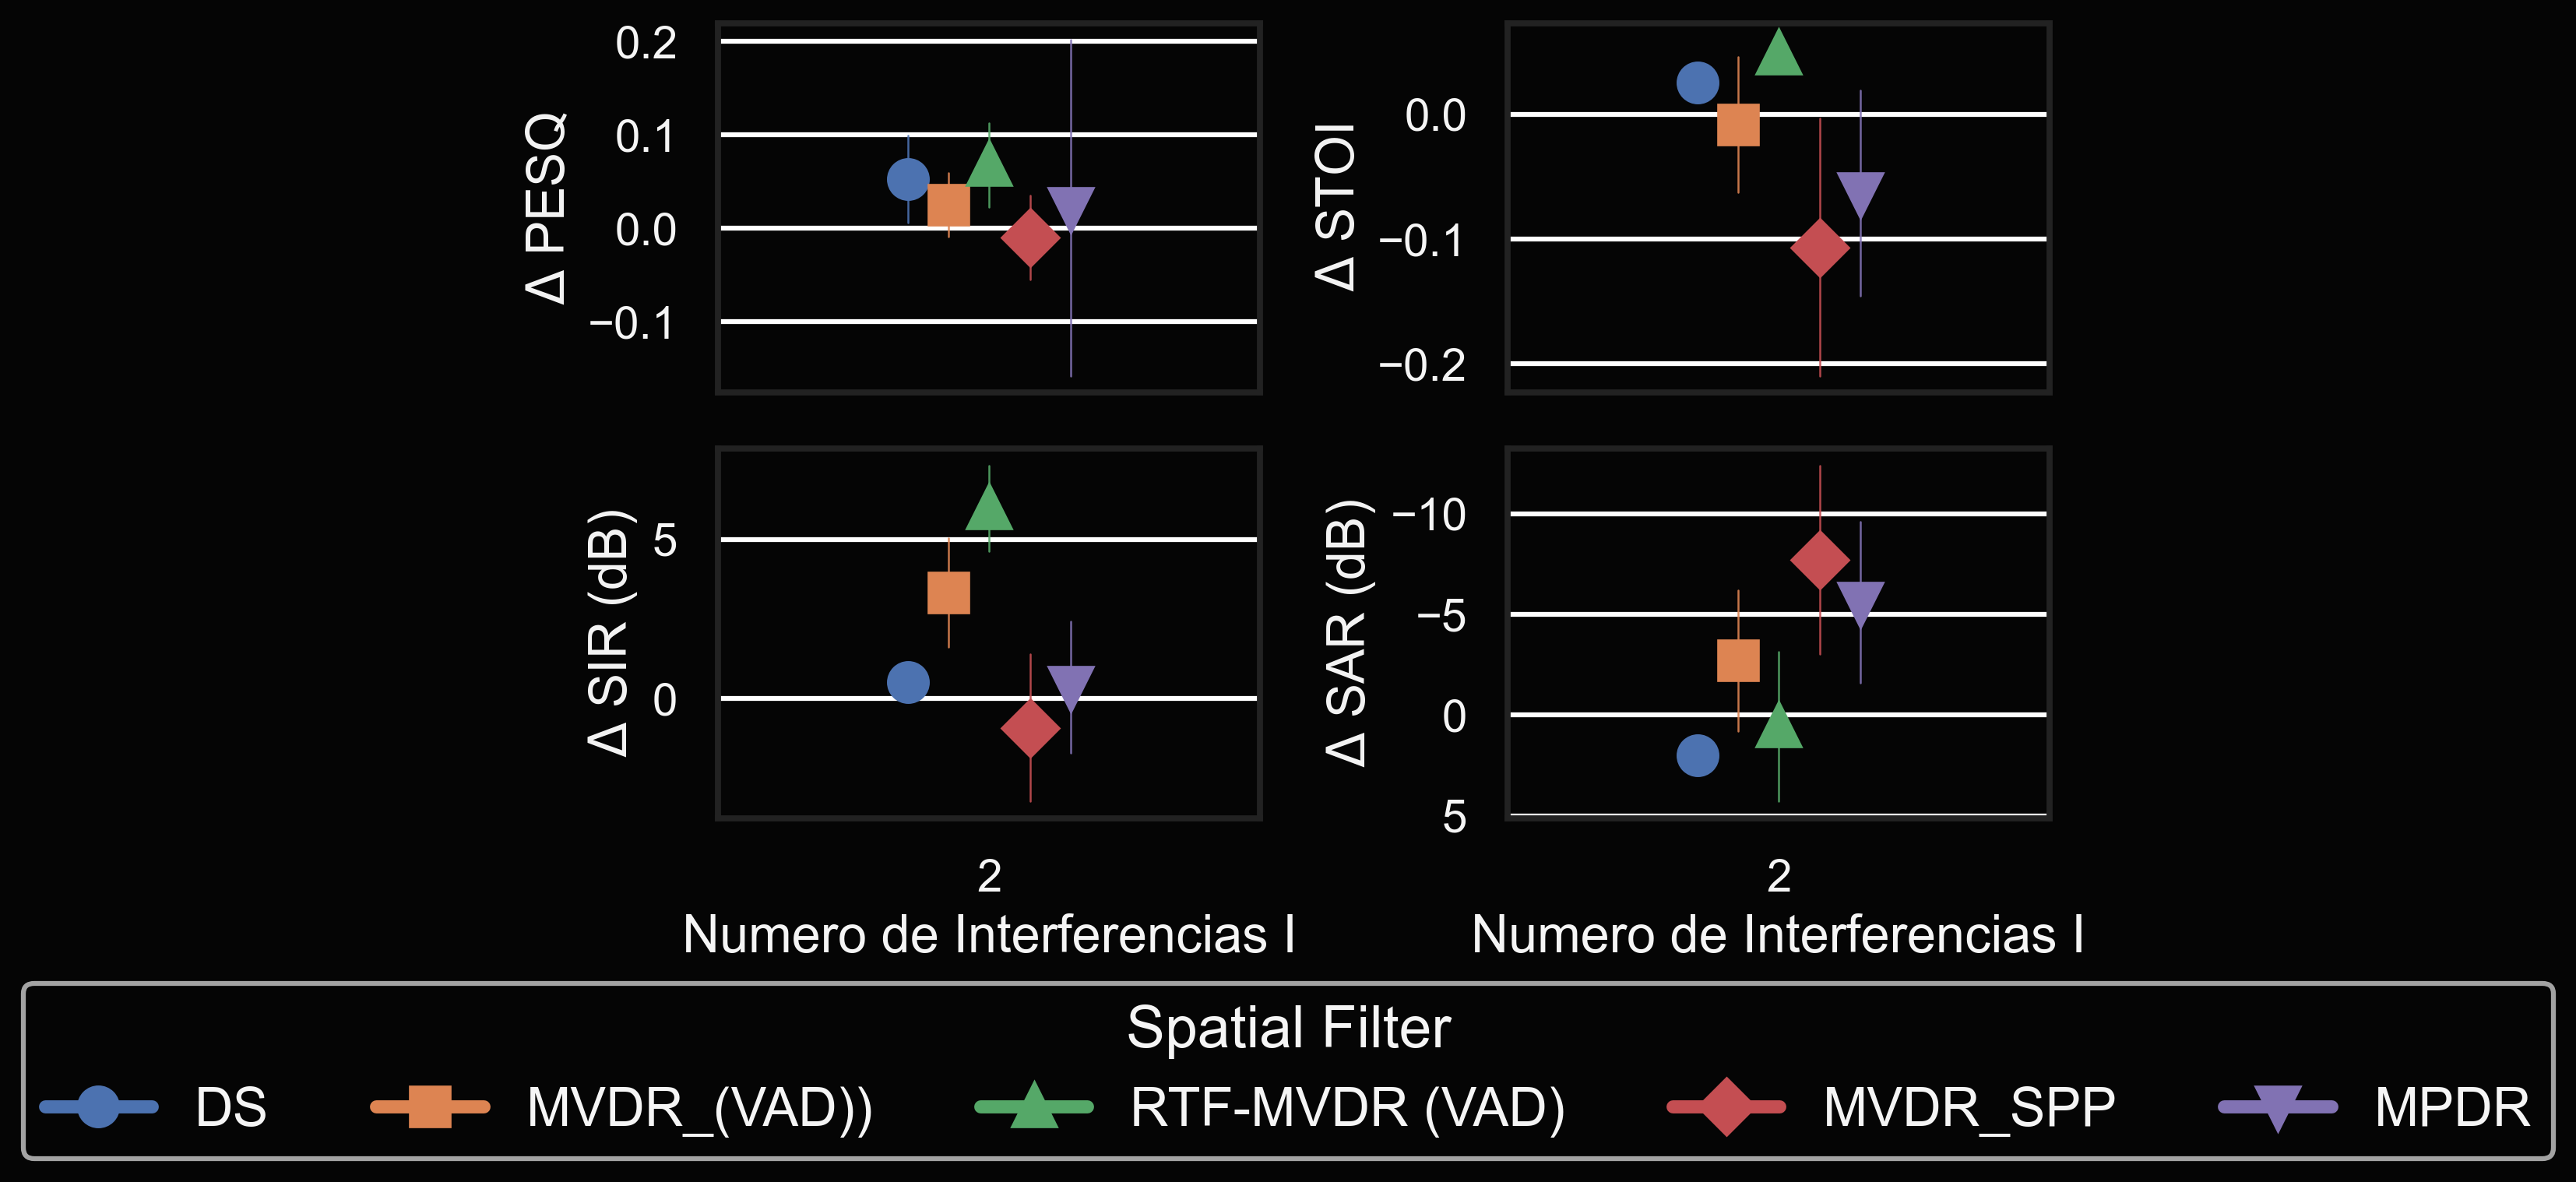

In [49]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == False].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='N_interferences',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        # -------------------------------------------------------------
        # INVERT Y-AXIS SPECIFICALLY FOR SAR
        # -------------------------------------------------------------

        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Numero de Interferencias I') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

        if 'SAR' in metric_col:
            ax.invert_yaxis()     
        

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_vs_interferences.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\t60_sin_wpe.pdf


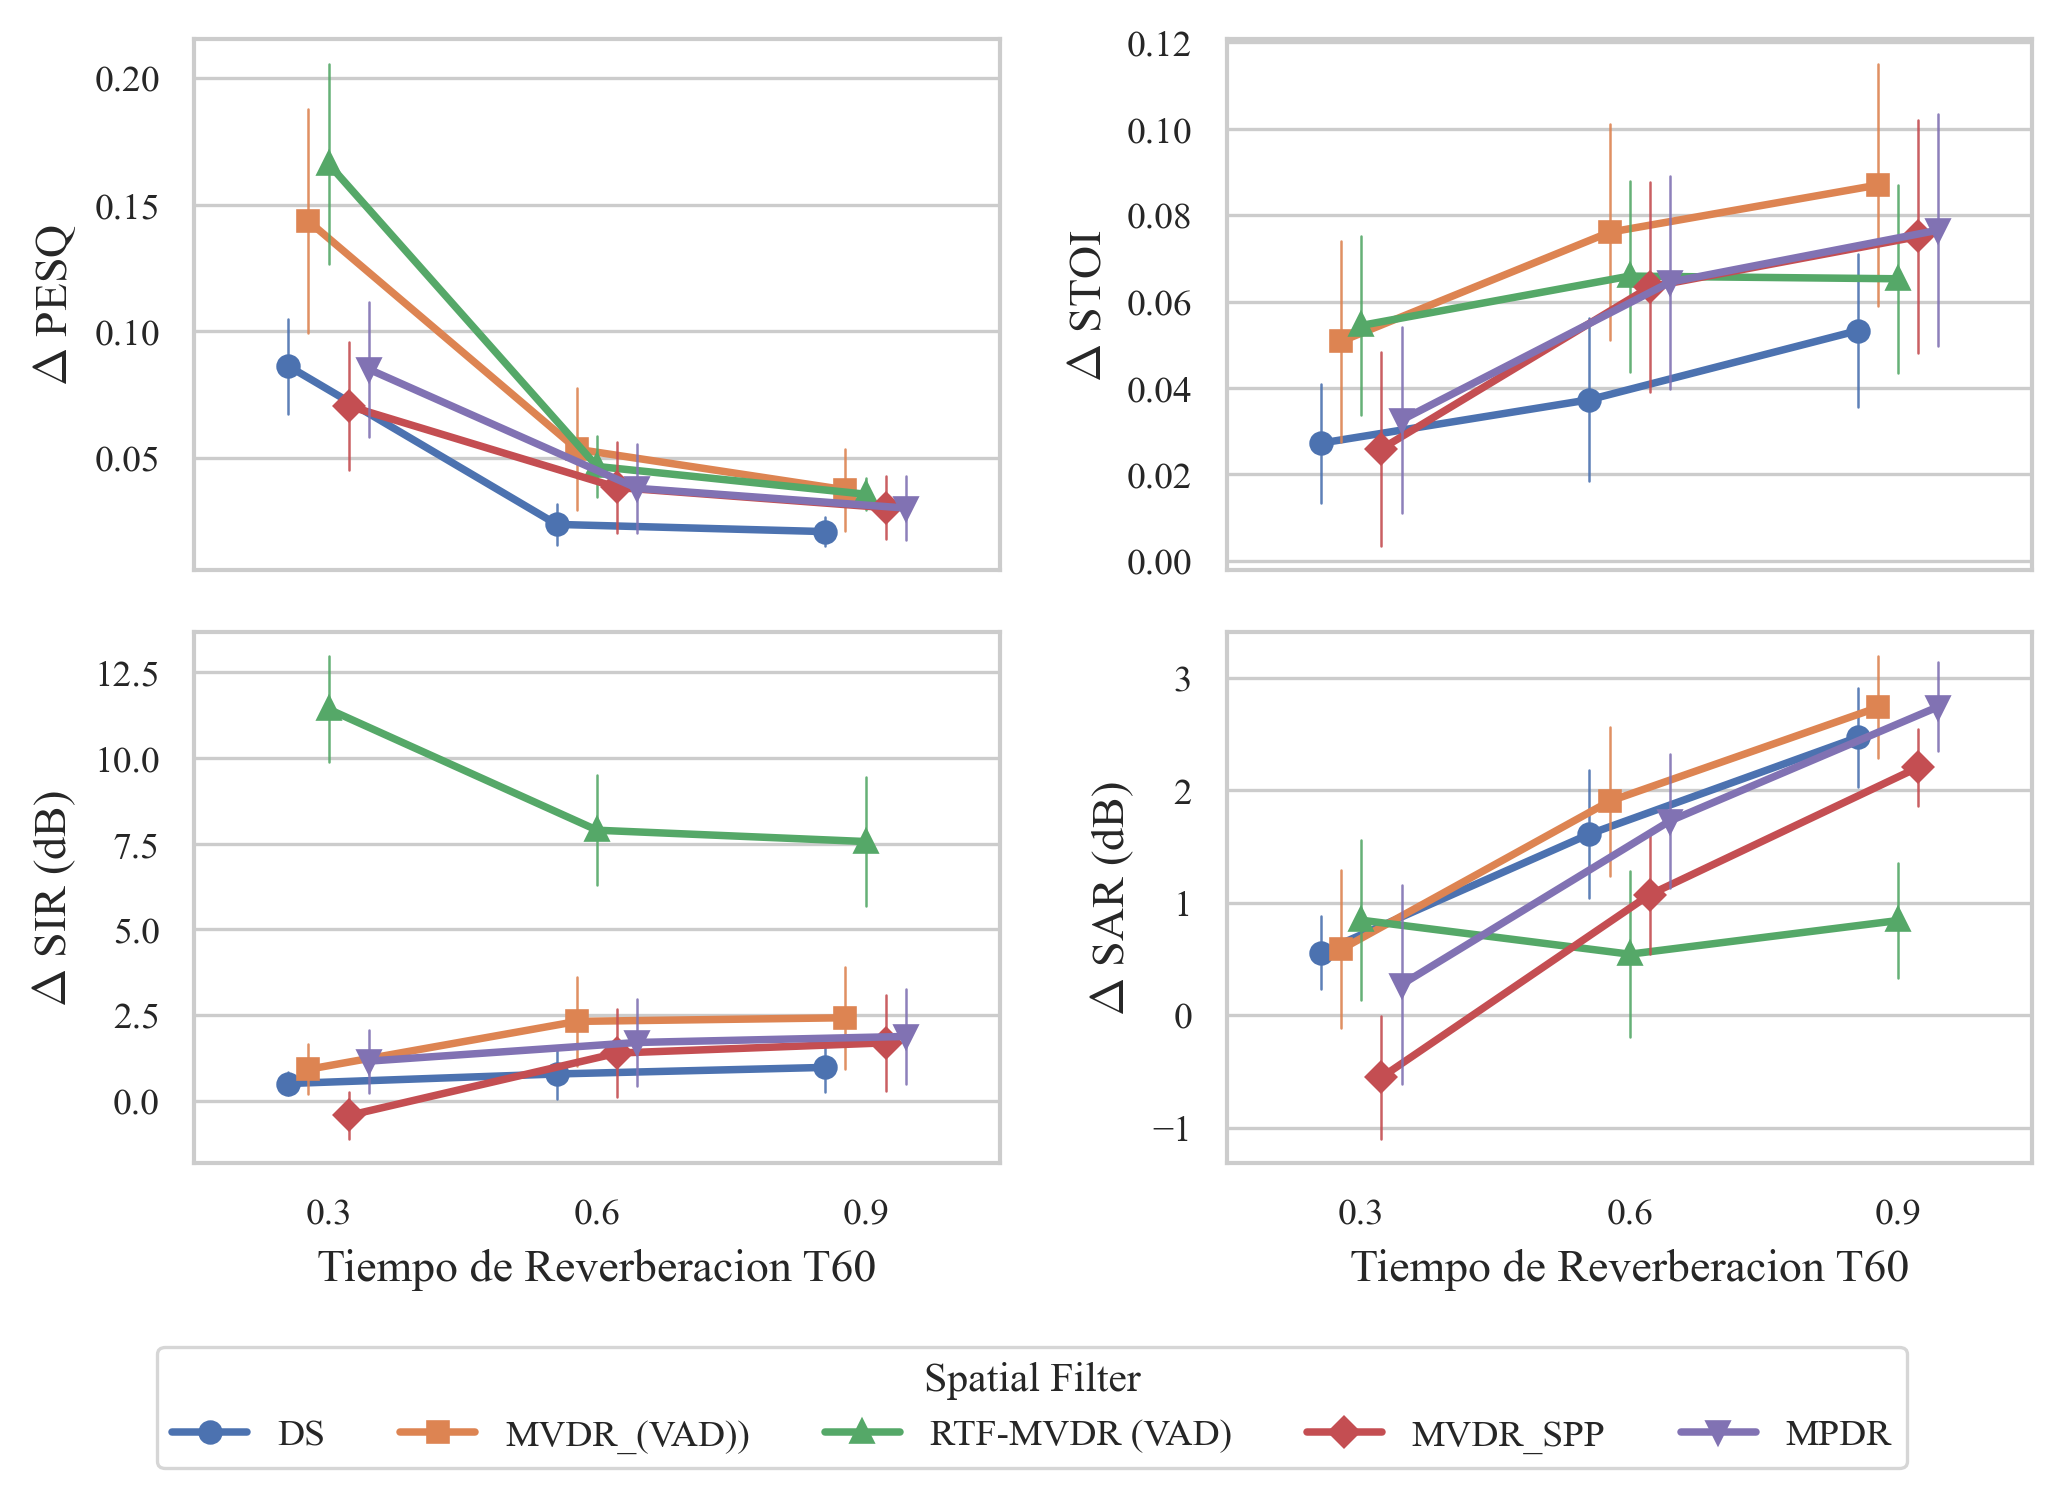

In [123]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == False].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2,figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='rt60',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberacion T60') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "t60_sin_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

Figure saved successfully at:
C:\Users\Matias\Documents\Tesis\Tesis_Latex\Figuras\Formato\eval_1\t60_con_wpe.pdf


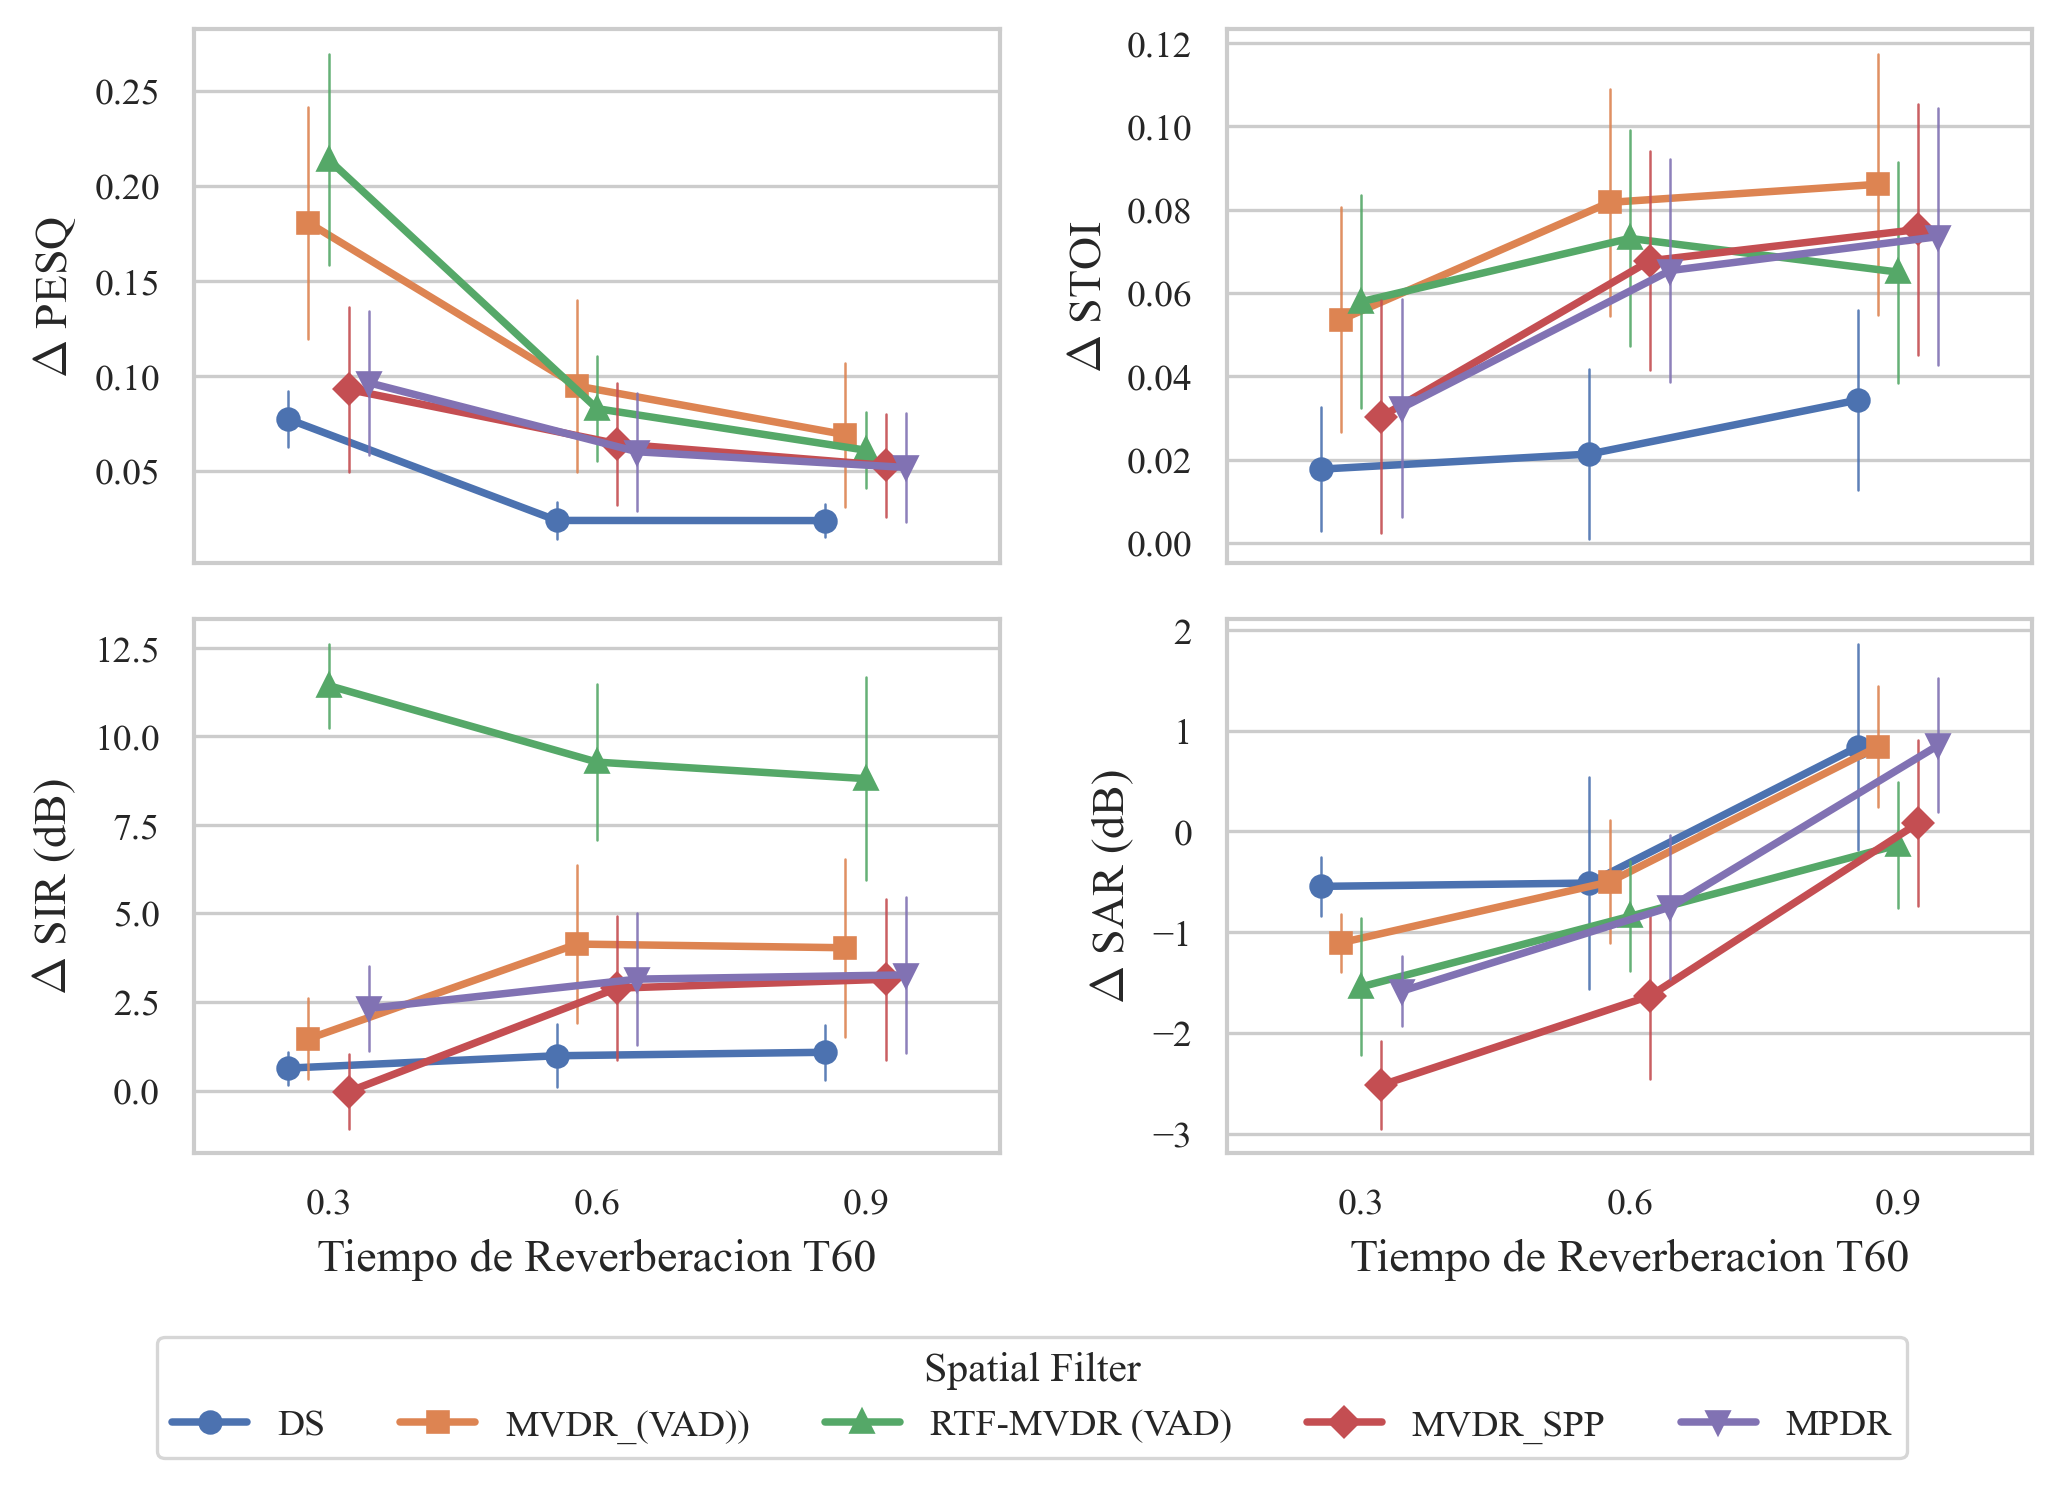

In [125]:
# ==============================================================================
# BLOCK 3: GENERATE BEAMFORMER PERFORMANCE PLOT VS INTERFERENCES (WITHOUT WPE)
# ==============================================================================

def plot_beamformer_deltas_vs_interferences_compact(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR) 
    introduced exclusively by the beamformer.
    Removes subplot titles and places the metric name directly on the Y-axis.
    Evaluates performance against the Numero de Interferencias I.
    """
    # Filter dataset: Only use cases where WPE is bypassed
    df_plot = df[df['use_wpe'] == True].copy()
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, figsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Get unique processors to assign markers properly
    processors = df_plot['processor'].unique()
    markers = ['o', 's', '^', 'D', 'v', 'p'][:len(processors)]
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot with discrete error styling
        sns.pointplot(
            data=df_plot, 
            x='rt60',   # Changed X-axis variable to Numero de Interferencias I
            y=metric_col, 
            hue='processor', 
            dodge=0.3,           
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberacion T60') # Updated label
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Spatial Filter',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=len(processors),        
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "t60_con_wpe.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function
plot_beamformer_deltas_vs_interferences_compact(df_metrics)

In [126]:
# ==============================================================================
# BLOCK 4: GENERATE WPE COMPARISON PLOT (AVERAGED ACROSS ALL PROCESSORS)
# ==============================================================================

def plot_wpe_comparison_vs_rt60(df):
    """
    Generates a 2x2 grid plotting the performance delta (PESQ, STOI, SIR, SAR).
    Averages the performance of all spatial filters and compares the results 
    with and without WPE pre-processing over different reverberation times.
    """
    # We need the full dataset (no WPE filter applied here)
    df_plot = df.copy()
    
    # Create a new column with readable labels for the legend
    df_plot['Condición WPE'] = df_plot['use_wpe'].map({True: 'Con WPE', False: 'Sin WPE'})
    
    # Define the metrics to plot and their corresponding Y-axis labels
    metrics_to_plot = {
        'Delta_bf_PESQ': r'$\Delta$ PESQ',
        'Delta_bf_STOI': r'$\Delta$ STOI',
        'Delta_bf_SIR': r'$\Delta$ SIR (dB)',
        'Delta_bf_SAR': r'$\Delta$ SAR (dB)'
    }
    
    # Create a 2x2 subplot grid
    fig, axes = plt.subplots(2, 2, pdffigsize=(7, 4.5), sharex=True)
    axes = axes.flatten()
    
    # Only two markers needed now
    markers = ['o', 's']
    
    # Generate each subplot
    for idx, (metric_col, y_label) in enumerate(metrics_to_plot.items()):
        ax = axes[idx]
        
        # Pointplot will automatically calculate the mean of all processors
        sns.pointplot(
            data=df_plot, 
            x='rt60',                 # Evaluated against reverberation time
            y=metric_col, 
            hue='Condición WPE',      # Hue changed to WPE status
            dodge=0.1,                # Reduced dodge since there are only 2 lines
            markers=markers,
            linestyles='-',
            errorbar='sd',
            err_kws={'linewidth': 0.6, 'alpha': 0.9}, 
            capsize=0,           
            ax=ax
        )
        
        # Formatting the subplot (No titles, just axes labels)
        ax.set_xlabel('Tiempo de Reverberación ($RT_{60}$)')
        ax.set_ylabel(y_label)
        
        # Remove the default legend generated by seaborn inside the axes
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Adjust layout to prevent text overlapping among subplots
    plt.tight_layout()
    
    # Extract handles and labels for the global legend from the last processed axis
    handles, labels = ax.get_legend_handles_labels()
    
    # Add a single horizontal legend at the bottom of the figure
    fig.legend(
        handles, labels, 
        title='Pre-procesamiento',
        loc='center', 
        bbox_to_anchor=(0.5, -0.05), # Positioned below the subplots
        ncol=2,                      # Only two columns for the legend
        frameon=True, 
        framealpha=0.8
    )
    
    # Save the figure to the defined directory
    output_path = os.path.join(FIGURES_DIR, "deltas_vs_rt_wpe_sin_con.pdf")
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    print(f"Figure saved successfully at:\n{output_path}")
    
    # Display the plot
    plt.show()

# Execute the plotting function (pass the complete dataframe)
plot_wpe_comparison_vs_rt60(df_metrics)

AttributeError: Figure.set() got an unexpected keyword argument 'pdffigsize'